<a href="https://colab.research.google.com/github/Nijimbere722/lab-3/blob/main/lab_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


# Section 1

#### Part 1.1 — A single neuron is just a line

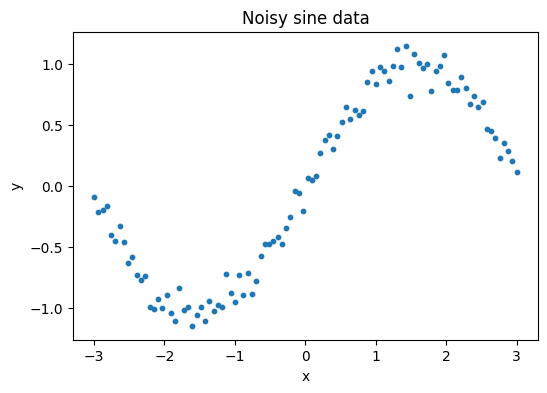

In [3]:
# Generate the toy data
x = np.linspace(-3, 3, 100)
y = np.sin(x) + np.random.normal(0, 0.1, size=x.shape)

plt.figure(figsize=(6,4))
plt.scatter(x, y, s=10)
plt.title("Noisy sine data")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [4]:
# Initialise w and b to small random values
np.random.seed(RANDOM_STATE)
w = np.random.randn() * 0.1
b = np.random.randn() * 0.1

lr = 0.1
steps = 200
losses = []

for step in range(steps):
    # Forward pass
    y_hat = w * x + b
    loss = np.mean((y_hat - y) ** 2)
    losses.append(loss)

    # Gradients
    dw = np.mean(2 * (y_hat - y) * x)
    db = np.mean(2 * (y_hat - y))

    # Update
    w -= lr * dw
    b -= lr * db

print(f"Final w: {w:.4f}, b: {b:.4f}")
print(f"Final loss: {losses[-1]:.4f}")

Final w: 0.3390, b: -0.0104
Final loss: 0.1955


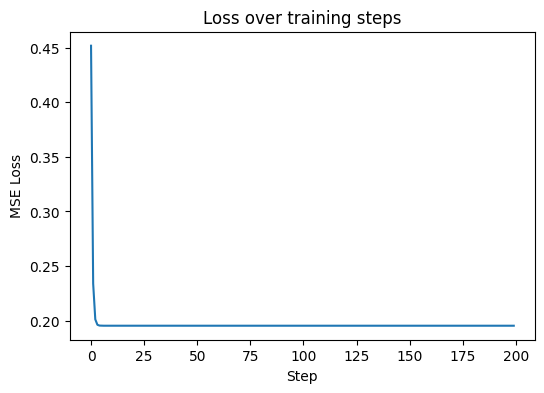

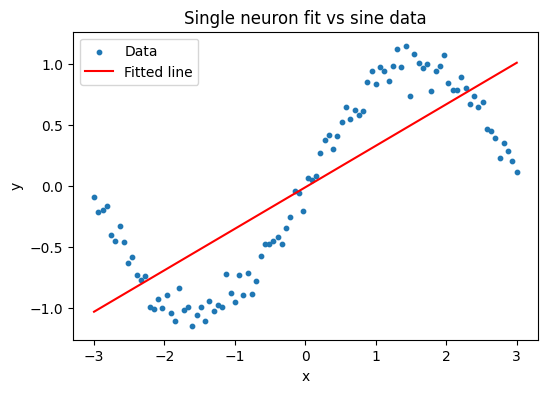

In [5]:
# Plot loss curve
plt.figure(figsize=(6,4))
plt.plot(losses)
plt.title("Loss over training steps")
plt.xlabel("Step")
plt.ylabel("MSE Loss")
plt.show()

# Plot data with fitted line
plt.figure(figsize=(6,4))
plt.scatter(x, y, s=10, label="Data")
plt.plot(x, w*x + b, color="red", label="Fitted line")
plt.title("Single neuron fit vs sine data")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

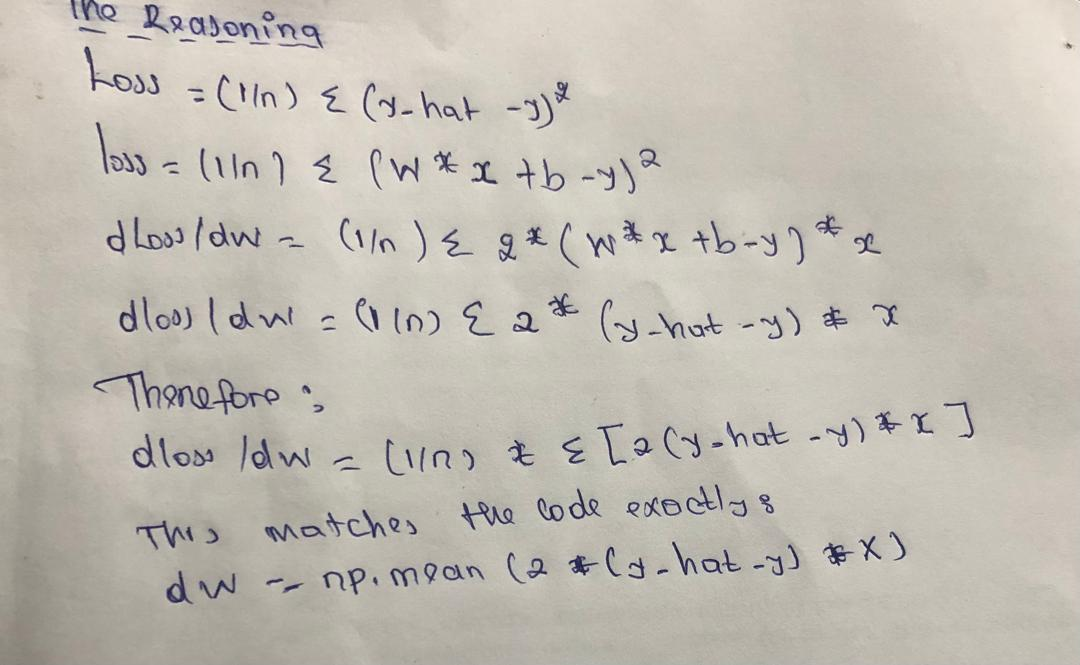

#### Part 1.2

In [6]:
# Initialise parameters
np.random.seed(RANDOM_STATE)
W1 = np.random.randn(1, 8) * 0.5
b1 = np.zeros(8)
W2 = np.random.randn(8, 1) * 0.5
b2 = np.zeros(1)

lr = 0.05
steps = 3000
losses_hidden = []

x_col = x.reshape(-1, 1)
y_col = y.reshape(-1, 1)

for step in range(steps):
    # Forward pass
    z1 = x_col @ W1 + b1
    h = np.tanh(z1)
    y_hat = h @ W2 + b2
    loss = np.mean((y_hat - y_col) ** 2)
    losses_hidden.append(loss)

    # Backward pass
    d_yhat = 2 * (y_hat - y_col) / len(y_col)
    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis=0)
    dh = d_yhat @ W2.T
    dz1 = dh * (1 - np.tanh(z1) ** 2)
    dW1 = x_col.T @ dz1
    db1 = dz1.sum(axis=0)

    # Update
    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2

print(f"Final loss: {losses_hidden[-1]:.4f}")

Final loss: 0.0150


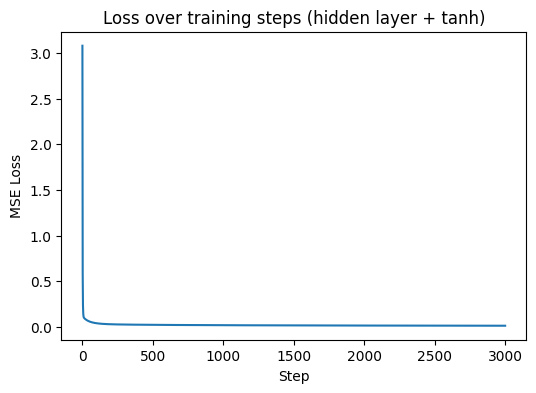

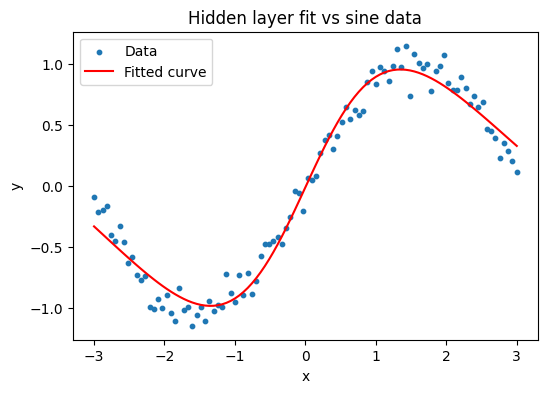

In [7]:
# Plot loss curve and final fit
plt.figure(figsize=(6,4))
plt.plot(losses_hidden)
plt.title("Loss over training steps (hidden layer + tanh)")
plt.xlabel("Step")
plt.ylabel("MSE Loss")
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(x, y, s=10, label="Data")
plt.plot(x, y_hat, color="red", label="Fitted curve")
plt.title("Hidden layer fit vs sine data")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

Final loss (no tanh): 0.1955


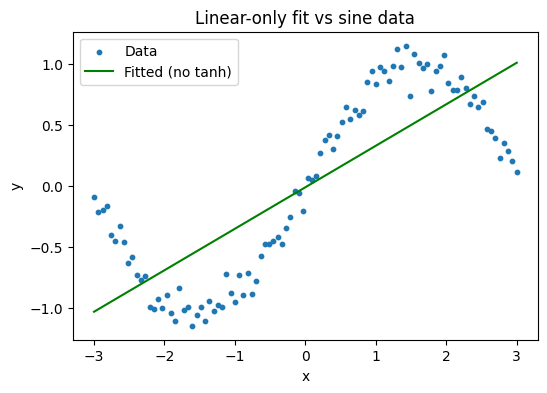

In [8]:
# Re-run WITHOUT tanh (linear only)
np.random.seed(RANDOM_STATE)
W1_lin = np.random.randn(1, 8) * 0.5
b1_lin = np.zeros(8)
W2_lin = np.random.randn(8, 1) * 0.5
b2_lin = np.zeros(1)

losses_linear = []

for step in range(steps):
    z1 = x_col @ W1_lin + b1_lin
    h = z1
    y_hat_lin = h @ W2_lin + b2_lin
    loss = np.mean((y_hat_lin - y_col) ** 2)
    losses_linear.append(loss)

    d_yhat = 2 * (y_hat_lin - y_col) / len(y_col)
    dW2_lin = h.T @ d_yhat
    db2_lin = d_yhat.sum(axis=0)
    dh = d_yhat @ W2_lin.T
    dz1 = dh
    dW1_lin = x_col.T @ dz1
    db1_lin = dz1.sum(axis=0)

    W1_lin -= lr * dW1_lin
    b1_lin -= lr * db1_lin
    W2_lin -= lr * dW2_lin
    b2_lin -= lr * db2_lin

print(f"Final loss (no tanh): {losses_linear[-1]:.4f}")

plt.figure(figsize=(6,4))
plt.scatter(x, y, s=10, label="Data")
plt.plot(x, y_hat_lin, color="green", label="Fitted (no tanh)")
plt.title("Linear-only fit vs sine data")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

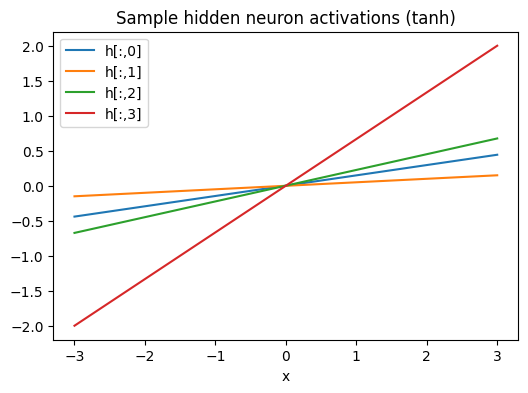

In [9]:
# plot first 4 hidden neurons
plt.figure(figsize=(6,4))
for i in range(4):
    plt.plot(x, h[:, i], label=f"h[:,{i}]")
plt.title("Sample hidden neuron activations (tanh)")
plt.xlabel("x")
plt.legend()
plt.show()

## Reasoning

1.Without tanh, the network computes y_hat = (x·W1 + b1)·W2 + b2, which simplifies to x·(W1·W2) + (b1·W2 + b2). This is just w*x + b with a new combined weight and bias algebraically identical to a single linear layer, no matter how many linear layers you stack. That's why it matched Part 1.1's loss of 0.1955.

2.Each of the 8 hidden neurons learns its own tanh-shaped bend of x, activating at a different point. The output layer combines these 8 curved pieces into one smooth curve, like building a sine wave out of several overlapping S-curves. This is only possible because tanh is nonlinear; without it, there's nothing to combine into a curve.

3.Backpropagation is using the chain rule to work backward from the loss and calculate how much each weight and bias contributed to the error.

#### Part 1.3

In [11]:
import warnings
warnings.filterwarnings("ignore")
np.seterr(all="ignore")

{'divide': 'warn', 'over': 'warn', 'under': 'ignore', 'invalid': 'warn'}

In [13]:
import warnings
warnings.filterwarnings("ignore")
np.seterr(all="ignore")

def train_toy(lr, steps=3000):
    np.random.seed(RANDOM_STATE)
    W1 = np.random.randn(1, 8) * 0.5
    b1 = np.zeros(8)
    W2 = np.random.randn(8, 1) * 0.5
    b2 = np.zeros(1)

    losses = []
    for step in range(steps):
        z1 = x_col @ W1 + b1
        h = np.tanh(z1)
        y_hat = h @ W2 + b2
        loss = np.mean((y_hat - y_col) ** 2)
        losses.append(loss)

        d_yhat = 2 * (y_hat - y_col) / len(y_col)
        dW2 = h.T @ d_yhat
        db2 = d_yhat.sum(axis=0)
        dh = d_yhat @ W2.T
        dz1 = dh * (1 - np.tanh(z1) ** 2)
        dW1 = x_col.T @ dz1
        db1 = dz1.sum(axis=0)

        W1 -= lr * dW1
        b1 -= lr * db1
        W2 -= lr * dW2
        b2 -= lr * db2

    return losses

losses_low = train_toy(lr=0.001)
losses_mid = train_toy(lr=0.05)
losses_high = train_toy(lr=1.0)

print("Final loss (lr=0.001):", losses_low[-1])
print("Final loss (lr=0.05):", losses_mid[-1])
print("Final loss (lr=1.0):", losses_high[-1])

Final loss (lr=0.001): 0.05549205437766945
Final loss (lr=0.05): 0.015034009965287823
Final loss (lr=1.0): nan


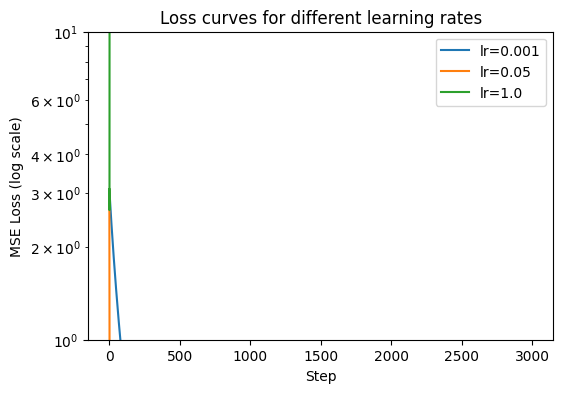

In [14]:
plt.figure(figsize=(6,4))
plt.plot(losses_low, label="lr=0.001")
plt.plot(losses_mid, label="lr=0.05")
plt.plot(losses_high, label="lr=1.0")
plt.yscale("log")
plt.title("Loss curves for different learning rates")
plt.xlabel("Step")
plt.ylabel("MSE Loss (log scale)")
plt.legend()
plt.show()

#### Reasoning

lr=0.001 (too cold): The loss barely decreases over 3000 steps — each update is too small, so the model learns extremely slowly and never reaches a good fit in the given time.

lr=0.05 (just right): The loss drops quickly and smoothly, settling at a low value (~0.015). this is a well-balanced step size for this problem.

lr=1.0 (too hot): The loss explodes to nan almost immediately. A learning rate this large causes each weight update to overshoot the minimum by such a large margin that the weights grow uncontrollably with every step, eventually exceeding what a computer can represent numerically. It's not "learning faster"  it's failing to converge at all, since each step moves further from the minimum instead of closer to it.

# Section 2

#### Part2.1

In [15]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"
obesity = pd.read_csv(OBESITY_URL)

obesity.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [17]:
df = obesity.copy()

# Binary yes/no columns -> 0/1
binary_cols = ["family_history_with_overweight", "FAVC", "SMOKE", "SCC"]
for col in binary_cols:
    df[col] = df[col].map({"yes": 1, "no": 0})

# Gender
df["Gender"] = df["Gender"].map({"Male": 0, "Female": 1})

df = pd.get_dummies(df, columns=["CAEC", "CALC", "MTRANS"], drop_first=False)

# Encode target NObeyesdad into integers 0-6
target_encoder = LabelEncoder()
df["NObeyesdad"] = target_encoder.fit_transform(df["NObeyesdad"])

print(df.shape)
df.head()

(2111, 27)


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,SMOKE,CH2O,...,CAEC_no,CALC_Always,CALC_Frequently,CALC_Sometimes,CALC_no,MTRANS_Automobile,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
0,1,21.0,1.62,64.0,1,0,2.0,3.0,0,2.0,...,False,False,False,False,True,False,False,False,True,False
1,1,21.0,1.52,56.0,1,0,3.0,3.0,1,3.0,...,False,False,False,True,False,False,False,False,True,False
2,0,23.0,1.80,77.0,1,0,2.0,3.0,0,2.0,...,False,False,True,False,False,False,False,False,True,False
3,0,27.0,1.80,87.0,0,0,3.0,3.0,0,2.0,...,False,False,True,False,False,False,False,False,False,True
4,0,22.0,1.78,89.8,0,0,2.0,1.0,0,2.0,...,False,False,False,True,False,False,False,False,True,False


In [18]:
# Separate features and target
X = df.drop(columns=["NObeyesdad"])
y_target = df["NObeyesdad"]

# Convert any remaining True/False columns to 0/1
X = X.astype(float)

# Stratified train/val/test split (60/20/20)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_target, test_size=0.4, stratify=y_target, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=RANDOM_STATE
)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

# Scale using StandardScaler fit on training data only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Scaling done.")

Train: (1266, 26) Val: (422, 26) Test: (423, 26)
Scaling done.


In [19]:
# Convert to tensors
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.long)

X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_t = torch.tensor(y_val.values, dtype=torch.long)

X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_t = torch.tensor(y_test.values, dtype=torch.long)

# Wrap in datasets and dataloaders
train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_val_t, y_val_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("DataLoaders ready.")
print("Input dimension:", X_train_t.shape[1])

DataLoaders ready.
Input dimension: 26


#### Reasoning

1. CrossEntropyLoss expects integer class labels (not one-hot vectors) because it internally applies log-softmax and then picks out the log-probability of the correct class using the integer as an index. This is more memory-efficient than passing full one-hot vectors, and PyTorch handles the "correctness" comparison internally.

2. A random forest splits data based on thresholds (e.g. "is Weight > 80?"), so the actual scale of numbers doesn't matter — only the order does. Neural networks, however, learn through gradient descent, and from Section 1 we saw that gradients like dw = mean(2*(y_hat-y)*x) scale directly with x. If one feature (like Weight, in the hundreds) is much larger than another (like FCVC, between 1-3), it dominates the gradient updates and makes training unstable or slow — scaling puts every feature on equal footing.

3. shuffle=True randomizes the order of training examples each epoch. This prevents the model from learning any accidental pattern based on the order of the data (e.g. if all one class was grouped together), and helps gradient descent generalize better instead of overfitting to a fixed sequence.

#### Part2.2

In [20]:
class FeedForwardNet(nn.Module):
    def __init__(self, input_dim, hidden_sizes=(64, 32), n_classes=7):
        super().__init__()
        layers = []
        prev_size = input_dim
        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(nn.ReLU())
            prev_size = hidden_size
        layers.append(nn.Linear(prev_size, n_classes))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

# Instantiate
model = FeedForwardNet(input_dim=26, hidden_sizes=(64, 32), n_classes=7)
model = model.to(DEVICE)
print(model)

FeedForwardNet(
  (network): Sequential(
    (0): Linear(in_features=26, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=7, bias=True)
  )
)


In [21]:
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Total trainable parameters:", total_params)

first_layer_params = 26 * 64 + 64
print("First layer parameter count (manual):", first_layer_params)

Total trainable parameters: 4039
First layer parameter count (manual): 1728


#### Reasoning
1.By-hand parameter count:

Layer 1 (input→64): 26*64 + 64 = 1728

Layer 2 (64→32): 64*32 + 32 = 2080

Layer 3 (32→7): 32*7 + 7 = 231

Total: 1728 + 2080 + 231 = 4039, which matches PyTorch's count exactly.

2.ReLU is used here instead of tanh because ReLU doesn't saturate for large positive inputs, tanh's gradient shrinks toward zero for very large or very small inputs (vanishing gradient), which slows down learning in deeper networks. ReLU keeps gradients flowing more easily since its gradient is either 0 or 1.

3.If the ReLUs were removed, the network would collapse into a single linear layer, exactly as shown in Part 1.2, the three stacked Linear layers would mathematically combine into one linear transformation, with no ability to model non-linear relationships in the data.

#### Part2.3

In [22]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
n_epochs = 50

train_losses, val_losses = [], []
train_accs, val_accs = [], []

best_val_acc = 0.0

for epoch in range(n_epochs):
    # Training
    model.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

    # Evaluation
    model.eval()
    with torch.no_grad():
        def evaluate(loader):
            total_loss, correct, total = 0.0, 0, 0
            for xb, yb in loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                logits = model(xb)
                loss = criterion(logits, yb)
                total_loss += loss.item() * xb.size(0)
                preds = logits.argmax(dim=1)
                correct += (preds == yb).sum().item()
                total += xb.size(0)
            return total_loss / total, correct / total

        train_loss, train_acc = evaluate(train_loader)
        val_loss, val_acc = evaluate(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "ffn_best.pt")

    print(f"Epoch {epoch+1}/{n_epochs} - train_loss: {train_loss:.4f}, train_acc: {train_acc:.4f}, val_loss: {val_loss:.4f}, val_acc: {val_acc:.4f}")

Epoch 1/50 - train_loss: 1.7333, train_acc: 0.5063, val_loss: 1.7416, val_acc: 0.4882
Epoch 2/50 - train_loss: 1.3430, train_acc: 0.5964, val_loss: 1.3771, val_acc: 0.5569
Epoch 3/50 - train_loss: 1.0066, train_acc: 0.6714, val_loss: 1.0658, val_acc: 0.6303
Epoch 4/50 - train_loss: 0.8130, train_acc: 0.7354, val_loss: 0.8942, val_acc: 0.6896
Epoch 5/50 - train_loss: 0.6918, train_acc: 0.7994, val_loss: 0.7976, val_acc: 0.7346
Epoch 6/50 - train_loss: 0.5928, train_acc: 0.8025, val_loss: 0.7259, val_acc: 0.7346
Epoch 7/50 - train_loss: 0.5117, train_acc: 0.8302, val_loss: 0.6617, val_acc: 0.7725
Epoch 8/50 - train_loss: 0.4437, train_acc: 0.8602, val_loss: 0.6117, val_acc: 0.7844
Epoch 9/50 - train_loss: 0.3809, train_acc: 0.8799, val_loss: 0.5632, val_acc: 0.8175
Epoch 10/50 - train_loss: 0.3335, train_acc: 0.9076, val_loss: 0.5282, val_acc: 0.8318
Epoch 11/50 - train_loss: 0.2979, train_acc: 0.9147, val_loss: 0.5013, val_acc: 0.8365
Epoch 12/50 - train_loss: 0.2692, train_acc: 0.9218,

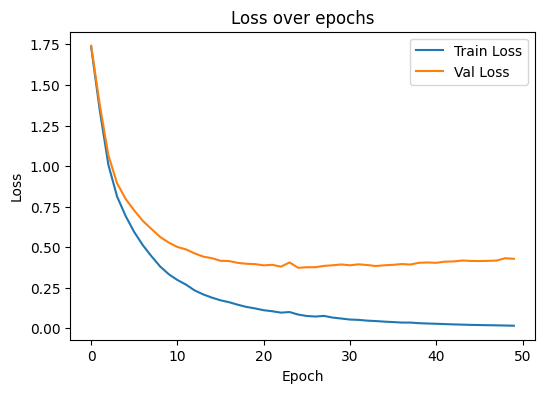

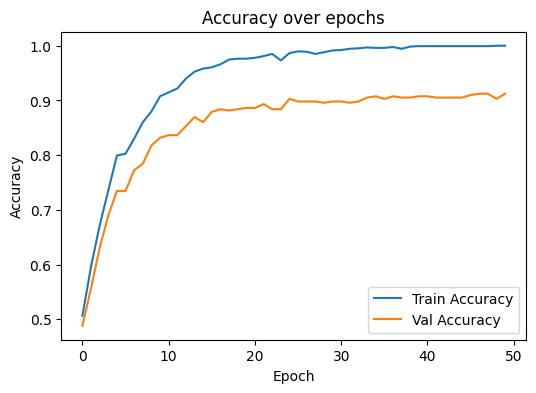

In [23]:
plt.figure(figsize=(6,4))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.title("Loss over epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Val Accuracy")
plt.title("Accuracy over epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

#### Reasoning

1.Logits = model(xb) is the forward pass, loss = criterion(logits, yb) computes the loss, loss.backward() computes all gradients automatically (replacing the manual dW1, db1, dW2, db2 from Section 1), and optimizer.step() applies the update rule (replacing W1 -= lr * dW1).

2.The model is overfitting. Train accuracy hit 1.0000 with train loss down to 0.0162, but val loss rose back up to 0.4285 while val accuracy stayed flat around 0.91, the model is memorizing training data instead of generalizing further.

3.Optimizer.zero_grad() clears old gradients before each batch. Without it, PyTorch would keep adding new gradients on top of old ones, corrupting the updates and breaking training.

#### Part 2.4:Experiments

In [24]:
def run_experiment(hidden_sizes=(64, 32), lr=1e-3, batch_size=32, epochs=50, dropout=0.0):
    # Build model with optional dropout
    layers = []
    prev_size = X_train_t.shape[1]
    for hidden_size in hidden_sizes:
        layers.append(nn.Linear(prev_size, hidden_size))
        layers.append(nn.ReLU())
        if dropout > 0:
            layers.append(nn.Dropout(dropout))
        prev_size = hidden_size
    layers.append(nn.Linear(prev_size, 7))
    exp_model = nn.Sequential(*layers).to(DEVICE)

    exp_train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    exp_val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(exp_model.parameters(), lr=lr)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(epochs):
        exp_model.train()
        for xb, yb in exp_train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            logits = exp_model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

        exp_model.eval()
        with torch.no_grad():
            def evaluate(loader):
                total_loss, correct, total = 0.0, 0, 0
                for xb, yb in loader:
                    xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                    logits = exp_model(xb)
                    loss = criterion(logits, yb)
                    total_loss += loss.item() * xb.size(0)
                    preds = logits.argmax(dim=1)
                    correct += (preds == yb).sum().item()
                    total += xb.size(0)
                return total_loss / total, correct / total

            train_loss, train_acc = evaluate(exp_train_loader)
            val_loss, val_acc = evaluate(exp_val_loader)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

    return history

print("run_experiment function ready.")

run_experiment function ready.


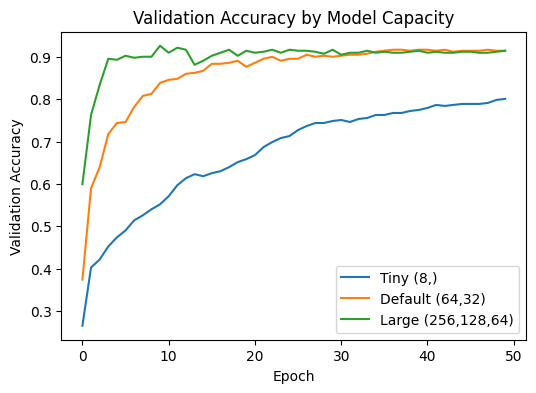

Final val acc - tiny: 0.8009478672985783
Final val acc - default: 0.9146919431279621
Final val acc - large: 0.9146919431279621


In [25]:
history_tiny = run_experiment(hidden_sizes=(8,))
history_default = run_experiment(hidden_sizes=(64, 32))
history_large = run_experiment(hidden_sizes=(256, 128, 64))

plt.figure(figsize=(6,4))
plt.plot(history_tiny["val_acc"], label="Tiny (8,)")
plt.plot(history_default["val_acc"], label="Default (64,32)")
plt.plot(history_large["val_acc"], label="Large (256,128,64)")
plt.title("Validation Accuracy by Model Capacity")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.show()

print("Final val acc - tiny:", history_tiny["val_acc"][-1])
print("Final val acc - default:", history_default["val_acc"][-1])
print("Final val acc - large:", history_large["val_acc"][-1])

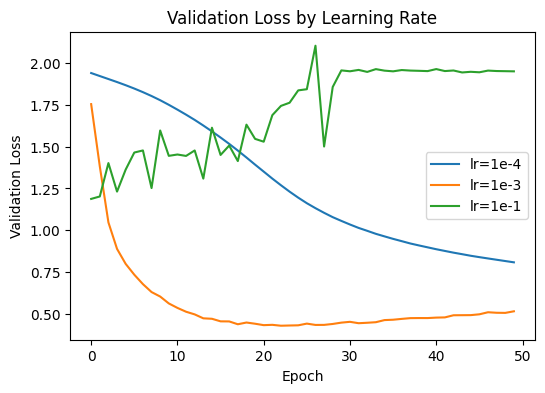

Final val loss - lr=1e-4: 0.8083324678136274
Final val loss - lr=1e-3: 0.515618627043485
Final val loss - lr=1e-1: 1.9502348679501864


In [26]:
#### Experiment B

history_lr_low = run_experiment(hidden_sizes=(64,32), lr=1e-4)
history_lr_mid = run_experiment(hidden_sizes=(64,32), lr=1e-3)
history_lr_high = run_experiment(hidden_sizes=(64,32), lr=1e-1)

plt.figure(figsize=(6,4))
plt.plot(history_lr_low["val_loss"], label="lr=1e-4")
plt.plot(history_lr_mid["val_loss"], label="lr=1e-3")
plt.plot(history_lr_high["val_loss"], label="lr=1e-1")
plt.title("Validation Loss by Learning Rate")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.show()

print("Final val loss - lr=1e-4:", history_lr_low["val_loss"][-1])
print("Final val loss - lr=1e-3:", history_lr_mid["val_loss"][-1])
print("Final val loss - lr=1e-1:", history_lr_high["val_loss"][-1])

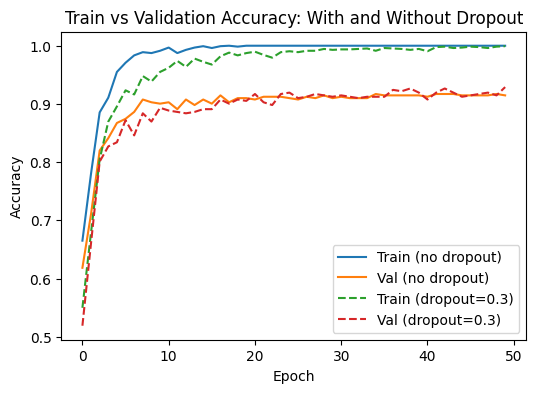

No dropout - final train acc: 1.0 final val acc: 0.9146919431279621
Dropout=0.3 - final train acc: 0.9992101105845181 final val acc: 0.9289099526066351


In [27]:
# Experiment C
history_large_no_dropout = run_experiment(hidden_sizes=(256, 128, 64), dropout=0.0)
history_large_dropout = run_experiment(hidden_sizes=(256, 128, 64), dropout=0.3)

plt.figure(figsize=(6,4))
plt.plot(history_large_no_dropout["train_acc"], label="Train (no dropout)")
plt.plot(history_large_no_dropout["val_acc"], label="Val (no dropout)")
plt.plot(history_large_dropout["train_acc"], label="Train (dropout=0.3)", linestyle="--")
plt.plot(history_large_dropout["val_acc"], label="Val (dropout=0.3)", linestyle="--")
plt.title("Train vs Validation Accuracy: With and Without Dropout")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

print("No dropout - final train acc:", history_large_no_dropout["train_acc"][-1], "final val acc:", history_large_no_dropout["val_acc"][-1])
print("Dropout=0.3 - final train acc:", history_large_dropout["train_acc"][-1], "final val acc:", history_large_dropout["val_acc"][-1])

#### Reasoning

1.Capacity: The large network (256,128,64) tied with the default (64,32) at ~91.5% val accuracy, and it didn't win. This shows diminishing returns: once the network is big enough to learn the patterns in this dataset, extra parameters don't help and just add unnecessary complexity.

2.Learning rate: Yes, same pattern as Part 1.3. 1e-4 was too slow (val loss stuck high at 0.81). 1e-3 was just right (lowest val loss, 0.52). 1e-1 was too aggressive (val loss spiked to 1.95, unstable).

3.Dropout improved val accuracy (91.5% up to 92.9%) while train accuracy barely changed, closing the train-val gap. Dropout randomly turns off some neurons during training, so the network can't rely too heavily on any one neuron, this forces it to learn more general patterns instead of memorizing the training data.

#### Part2.5: Final Evaluation

In [28]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay

# Load best model weights
best_model = FeedForwardNet(input_dim=26, hidden_sizes=(64, 32), n_classes=7).to(DEVICE)
best_model.load_state_dict(torch.load("ffn_best.pt"))
best_model.eval()

# Get predictions on test set
all_preds, all_labels = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(DEVICE)
        logits = best_model(xb)
        preds = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(yb.numpy())

test_acc = accuracy_score(all_labels, all_preds)
test_f1 = f1_score(all_labels, all_preds, average="macro")

print("Test Accuracy:", test_acc)
print("Test Macro-F1:", test_f1)
print(classification_report(all_labels, all_preds, target_names=target_encoder.classes_))

Test Accuracy: 0.9243498817966903
Test Macro-F1: 0.9225931488411753
                     precision    recall  f1-score   support

Insufficient_Weight       0.96      0.91      0.93        54
      Normal_Weight       0.76      0.83      0.79        58
     Obesity_Type_I       0.99      0.96      0.97        70
    Obesity_Type_II       1.00      0.97      0.98        60
   Obesity_Type_III       0.98      1.00      0.99        65
 Overweight_Level_I       0.84      0.84      0.84        58
Overweight_Level_II       0.93      0.95      0.94        58

           accuracy                           0.92       423
          macro avg       0.92      0.92      0.92       423
       weighted avg       0.93      0.92      0.93       423



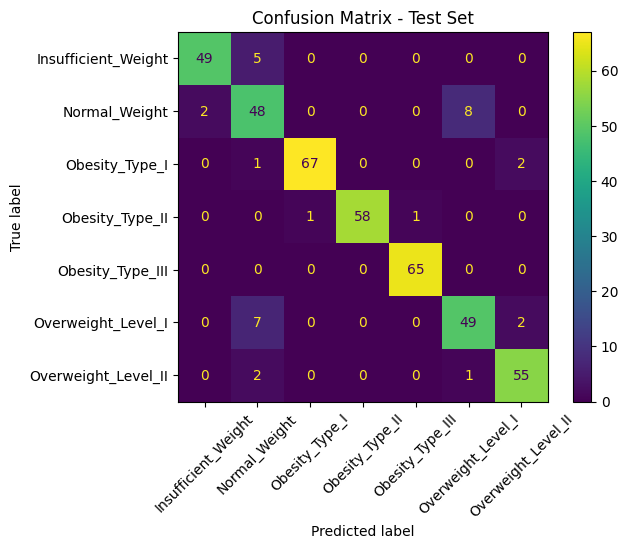

In [29]:
class_names = target_encoder.classes_
ConfusionMatrixDisplay.from_predictions(all_labels, all_preds, display_labels=class_names, xticks_rotation=45)
plt.title("Confusion Matrix - Test Set")
plt.show()

In [30]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Logistic Regression (Lab 2)", "Feedforward Neural Network (Lab 3)"],
    "Test Accuracy": [0.8936, test_acc],
    "Test Macro-F1": [0.8895, test_f1],
    "Parameters/Complexity": ["Linear coefficients (~26 features x 7 classes)", f"{total_params} trainable parameters"]
})

comparison

,Model,Test Accuracy,Test Macro-F1,Parameters/Complexity
0,Logistic Regression (Lab 2),0.89360,0.889500,Linear coefficients (~26 features x 7 classes)
1,Feedforward Neural Network (Lab 3),0.92435,0.922593,4039 trainable parameters


#### Reasoning
1.The network still confuses Normal_Weight and Overweight_Level_I the most (lowest precision/recall scores). These are the same two classes Logistic Regression struggled with in Lab 2 which makes sense, since they're right next to each other on a continuous weight scale rather than truly separate groups.

2.The neural network wins 92.4% accuracy and 0.923 macro-F1, beating Logistic Regression's 89.4% and 0.890. The improvement is worth it here, but Logistic Regression is much simpler and faster to train.